In [ ]:
from google.colab import userdata
import json

# Get the Kaggle credentials from Colab's userdata


username = userdata.get("KAGGLE_USER")
key = userdata.get("KAGGLE_KEY")


# Echo the credentials into the kaggle.json file
!mkdir -p ~/.kaggle
!echo '{{"username":"{username}","key":"{key}"}}' > ~/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
# Download dataset : UCI HAR Dataset from Kaggle
!kaggle competitions download -c spai-signal-sleep-staging-classification
# !unzip /content/ucihar-dataset.zip && rm -rf /content/ucihar-dataset.zip

In [ ]:
!unzip /content/spai-signal-sleep-staging-classification.zip && rm -rf /content/spai-signal-sleep-staging-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: test_segment/test_segment/test004/test004_00448.csv  
  inflating: test_segment/test_segment/test004/test004_00449.csv  
  inflating: test_segment/test_segment/test004/test004_00450.csv  
  inflating: test_segment/test_segment/test004/test004_00451.csv  
  inflating: test_segment/test_segment/test004/test004_00452.csv  
  inflating: test_segment/test_segment/test004/test004_00453.csv  
  inflating: test_segment/test_segment/test004/test004_00454.csv  
  inflating: test_segment/test_segment/test004/test004_00455.csv  
  inflating: test_segment/test_segment/test004/test004_00456.csv  
  inflating: test_segment/test_segment/test004/test004_00457.csv  
  inflating: test_segment/test_segment/test004/test004_00458.csv  
  inflating: test_segment/test_segment/test004/test004_00459.csv  
  inflating: test_segment/test_segment/test004/test004_00460.csv  
  inflating: test_segment/test_segment/test004/test004_00461.csv  
  inflating

In [ ]:
import os
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, iqr, entropy
from tqdm import tqdm # Import tqdm for progress tracking

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [ ]:
data_dir = "/content/train/train"
csv_files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".csv")]
df_list = [pd.read_csv(file) for file in csv_files]
df = pd.concat(df_list, ignore_index=True)

print(df.shape)  # Expected: (~25M, 9)

(32037600, 9)


In [ ]:
ex = pd.read_csv(r"/content/train/train/train036.csv")
ex

,BVP,ACC_X,ACC_Y,ACC_Z,TEMP,EDA,HR,IBI,Sleep_Stage
0,39.396571,40.653523,37.735755,63.765546,33.917260,1.453635,77.453137,0.803199,W
1,185.712797,31.899277,38.049353,62.289022,33.917252,1.453111,77.453131,0.803199,W
2,310.093202,41.498253,28.228736,71.443400,33.917262,1.456154,77.453140,0.803199,W
3,307.680135,-37.227452,34.890721,65.274350,33.917252,1.450763,77.453130,0.803199,W
4,363.449236,-52.136966,37.667794,45.075231,33.917259,1.456939,77.453138,0.803199,W
...,...,...,...,...,...,...,...,...,...
394075,-4.047171,-30.982746,27.625216,48.740114,35.251803,3.283809,71.452822,0.804879,W
394076,-7.937375,-30.828557,27.746240,48.403873,35.251803,3.276577,71.452168,0.800476,W
394077,-13.019345,-30.534505,27.612854,48.442996,35.251803,3.270872,71.453127,0.805538,W
394078,-19.255870,-30.711522,27.717294,48.441795,35.251803,3.272319,71.452208,0.800871,W


In [ ]:
window_size = 480
# Load your dataframe (df is assumed to have 9 columns: 8 features + 1 target) window_size = 480 # 16 Hz * 30 seconds
# Function to process data in 30-second segments
def process_segments (df, window_size):
  num_segments = len (df) // window_size # Number of 30-second windows processed_data
  processed_data = []
  for i in tqdm(range(num_segments), desc="Processing Segments", unit="window"):
    start_idx= i * window_size
    end_idx = (i + 1) * window_size
    segment = df.iloc[start_idx:end_idx] # Extract 30-second segment
    # Dictionary to store aggregated features
    feature_dict = {}

    for col in df.columns[:-1]: # Exclude the Sleep Stage column
      data = segment [col].values
      # Time-domain features
      feature_dict[f' {col}_mean'] = np.mean (data)
      feature_dict[f' {col}_std'] = np.std(data)
      feature_dict[f' {col}_mad'] = np.median(np.abs(data-np.median(data)))
      feature_dict[f' {col}_max'] = np.max(data)
      feature_dict[f' {col}_min'] = np.min(data)
      feature_dict[f' {col}_sma'] = np.sum(np.abs(data)) # Signal Magnitude Area
      feature_dict[f' {col}_energy'] = np.sum(np.square(data))
      feature_dict[f' {col}_iqr'] = iqr(data)
      feature_dict[f' {col}_skewness'] = skew(data)
      feature_dict[f' {col}_kurtosis'] = kurtosis(data)

      # Assign the sleep stage (take the first row's label) feature_dict['Sleep_Stage']
    feature_dict['Sleep_Stage'] = segment.iloc[0, -1] # Keep first label of window
    processed_data.append(feature_dict)  # Store in list
  return processed_data


In [ ]:
processed_data = process_segments(df,window_size)

Processing Segments:   0%|          | 0/66745 [00:00<?, ?window/s]<ipython-input-9-def94ad73759>:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  feature_dict[f' {col}_skewness'] = skew(data)
<ipython-input-9-def94ad73759>:26: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  feature_dict[f' {col}_kurtosis'] = kurtosis(data)
Processing Segments: 100%|██████████| 66745/66745 [15:11<00:00, 73.24window/s]


In [ ]:
print(processed_data[:5])  # View the first 5 processed segments

[{' BVP_mean': -0.055966848009883254, ' BVP std': 51.60013428900326, ' BVP_mad': 14.797657318793133, ' BVP_max': 394.0978910429936, ' BVP_min': -485.7268859485627, ' BVP sma': 11580.088394016755, ' BVP_energy': 1278036.9556469982, ' BVP_iqr': 30.62046106939921, ' BVP skewness': -1.0852827279150332, ' BVP_kurtosis': 37.48732652237919, ' ACC_X_mean': -62.37255062573181, ' ACC_X std': 0.43513972028608866, ' ACC_X_mad': 0.10769632711954813, ' ACC_X_max': -59.03755394585454, ' ACC_X_min': -65.61276949531124, ' ACC_X sma': 29938.82430035127, ' ACC_X_energy': 1867451.720705111, ' ACC_X_iqr': 0.26847010027447027, ' ACC_X skewness': 0.9312170136148814, ' ACC_X_kurtosis': 21.238848711873537, ' ACC_Y_mean': -10.473182818440891, ' ACC_Y std': 0.5356903803494091, ' ACC_Y_mad': 0.0009912096609943077, ' ACC_Y_max': -7.824372750732345, ' ACC_Y_min': -12.178110432458968, ' ACC_Y sma': 5027.1277528516275, ' ACC_Y_energy': 52787.77081540051, ' ACC_Y_iqr': 0.9885453033520637, ' ACC_Y skewness': 0.56800070

In [ ]:
df_processed = pd.DataFrame(processed_data)
print(df_processed.head())

    BVP_mean     BVP_std    BVP_mad     BVP_max     BVP_min       BVP_sma  \
0   0.589532   48.088372  23.980737  182.353864 -288.050171  15994.309668   
1  -1.055271  100.212063  29.809613  349.307196 -590.379050  29587.113579   
2   1.534201  173.916707  78.180016  745.029594 -788.491506  57984.374575   
3  -0.796307   61.852073  30.355877  257.586749 -433.192636  19926.635073   
4   0.196867   46.833564  35.112801   79.287650  -90.795329  19665.963412   

     BVP_energy     BVP_iqr   BVP_skewness   BVP_kurtosis  ...       IBI_std  \
0  1.110163e+06   47.791896      -0.722547       5.406473  ...  1.035105e-02   
1  4.820914e+06   59.671536      -1.162852       6.672816  ...  6.411181e-03   
2  1.451970e+07  158.591197      -0.285882       2.679578  ...  2.087441e-13   
3  1.836630e+06   66.633285      -1.613642      11.902190  ...  3.178003e-02   
4  1.052842e+06   81.057826      -0.388381      -1.138699  ...  9.975801e-03   

        IBI_mad   IBI_max   IBI_min     IBI_sma   IBI_en

In [ ]:
print(df_processed.shape)

(66745, 81)


In [ ]:
num_cols = df_processed.select_dtypes(include=['number']).columns

df_processed[num_cols] = df_processed.groupby('Sleep_Stage')[num_cols].transform(lambda x: x.fillna(x.mean()))

In [ ]:
x = df_processed.drop(columns=['Sleep_Stage']).values  # Features
y = df_processed['Sleep_Stage']  # Target variable


In [ ]:
x

array([[ 5.89532170e-01,  4.80883716e+01,  2.39807370e+01, ...,
         1.90958360e-14,  3.50126489e+00,  1.35196995e+01],
       [-1.05527138e+00,  1.00212063e+02,  2.98096134e+01, ...,
         2.84806073e-05,  1.33681000e+00, -2.01472747e-01],
       [ 1.53420060e+00,  1.73916707e+02,  7.81800156e+01, ...,
         5.55111512e-16, -5.36130974e+00,  1.04937785e+02],
       ...,
       [ 1.83208145e+00,  7.04880136e+01,  2.38992572e+01, ...,
         7.77156117e-16,  2.52317690e-01,  3.54371363e+00],
       [ 7.62534568e-02,  6.22151730e+01,  2.15193547e+01, ...,
         7.77156117e-16,  2.52317690e-01,  3.54371363e+00],
       [ 1.93740294e-01,  7.44578888e+01,  2.39523367e+01, ...,
         7.77156117e-16,  2.52317690e-01,  3.54371363e+00]])

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
# y_encoded = pd.get_dummies(y)
# print(y_encoded.head())

In [ ]:
y_encoded

array([4, 4, 4, ..., 1, 1, 1])

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y_encoded, test_size=0.3, stratify=y,random_state=42)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import accuracy_score, precision_score, balanced_accuracy_score
from sklearn.metrics import recall_score, f1_score,fbeta_score

In [ ]:
# LV0
from sklearn.ensemble import RandomForestClassifier                     #1
from sklearn.svm import SVC                                             #2
from sklearn.neighbors import KNeighborsClassifier                      #3
from xgboost import XGBClassifier, plot_importance                      #4
#LV 1
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import RandomizedSearchCV

In [ ]:
# def evaluate_model(name, model, y_pred, x_train, y_train, y_test):
#     decoded_y_test = np.array(y_test.columns)[np.argmax(y_test, axis=1)]
#     decoded_y_pred = np.array(y_pred.columns)[np.argmax(y_pred, axis=1)]

#     cfmx = confusion_matrix(decoded_y_test, decoded_y_pred)

#     plt.figure(figsize=(6, 4))
#     sns.heatmap(cfmx, annot=True, fmt='d', cmap='Blues',
#                 xticklabels=le.classes_,
#                 yticklabels=le.classes_)
#     plt.xlabel('Predicted')
#     plt.ylabel('Actual')
#     plt.title(f'Confusion Matrix for {name}')
#     plt.show()

#     print(f"Classification Report for {name}:\n")
#     print('Model Training Score', '{:.2f}'.format(model.score(x_train, y_train)))

#     try:
#         accuracy = accuracy_score(decoded_y_test, decoded_y_pred)
#         balanced_accuracy = balanced_accuracy_score(decoded_y_test, decoded_y_pred)
#         precision = precision_score(decoded_y_test, decoded_y_pred, average='weighted')
#         recall = recall_score(decoded_y_test, decoded_y_pred, average='weighted')
#         f1 = f1_score(decoded_y_test, decoded_y_pred, average='weighted')
#         f2 = fbeta_score(decoded_y_test, decoded_y_pred, average='weighted', beta=2)  # F2 score

#         print(f'Accuracy: {accuracy:.2f}')
#         print(f'Balanced Accuracy: {balanced_accuracy:.2f}')
#         print(f'Precision (weighted): {precision:.2f}')
#         print(f'Recall (weighted): {recall:.2f}')
#         print(f'F1 Score (weighted): {f1:.2f}')
#         print(f'F2 Score (weighted): {f2:.2f}')
#     except ValueError as e:
#         print(f"Error in metrics calculation for {name}: {e}")

#     try:
#         target_names = [str(label) for label in le.classes_]
#         print(classification_report(decoded_y_test, decoded_y_pred, target_names=target_names))
#     except ValueError as e:
#         print(f"Error in classification_report for {name}: {e}")

#     print("-" * 50)

In [ ]:
def evaluate_model(name, model, y_pred, x_train, y_train, y_test, le):
    """
    Evaluates the performance of a classification model.

    Parameters:
        name (str): Model name.
        model: Trained model object.
        y_pred (DataFrame or array): Predicted labels (one-hot encoded).
        x_train (array): Training feature set.
        y_train (array): Training labels.
        y_test (DataFrame or array): True labels (one-hot encoded).
        class_labels (list): List of class names (e.g., ['N', 'REM', 'W']).
    """

    decoded_y_test = le.inverse_transform(y_test)
    decoded_y_pred = le.inverse_transform(y_pred)

    # Confusion matrix
    cfmx = confusion_matrix(decoded_y_test, decoded_y_pred,labels=le.classes_)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cfmx, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix for {name}')
    plt.show()

    print(f"\nClassification Report for {name}:\n")
    print('Model Training Score:', '{:.2f}'.format(model.score(x_train, y_train)))

    try:
        accuracy = accuracy_score(decoded_y_test, decoded_y_pred)
        balanced_accuracy = balanced_accuracy_score(decoded_y_test, decoded_y_pred)
        precision = precision_score(decoded_y_test, decoded_y_pred, average='weighted')
        recall = recall_score(decoded_y_test, decoded_y_pred, average='weighted')
        f1 = f1_score(decoded_y_test, decoded_y_pred, average='weighted')
        f2 = fbeta_score(decoded_y_test, decoded_y_pred, average='weighted', beta=2)  # F2 score

        print(f'Accuracy: {accuracy:.2f}')
        print(f'Balanced Accuracy: {balanced_accuracy:.2f}')
        print(f'Precision (weighted): {precision:.2f}')
        print(f'Recall (weighted): {recall:.2f}')
        print(f'F1 Score (weighted): {f1:.2f}')
        print(f'F2 Score (weighted): {f2:.2f}')
    except ValueError as e:
        print(f"Error in metrics calculation for {name}: {e}")

    try:
        print(classification_report(decoded_y_test, decoded_y_pred, target_names=le.classes_))
    except ValueError as e:
        print(f"Error in classification_report for {name}: {e}")

    print("-" * 50)

In [ ]:
# Example class labels
class_labels = np.unique(y)

In [ ]:
print(class_labels)

['N1' 'N2' 'N3' 'R' 'W']


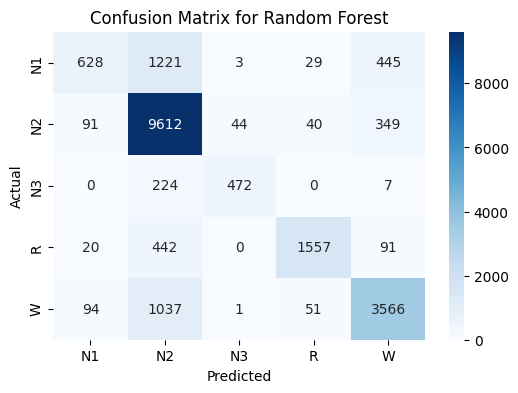


Classification Report for Random Forest:

Model Training Score: 1.00
Accuracy: 0.79
Balanced Accuracy: 0.68
Precision (weighted): 0.80
Recall (weighted): 0.79
F1 Score (weighted): 0.77
F2 Score (weighted): 0.78
              precision    recall  f1-score   support

          N1       0.75      0.27      0.40      2326
          N2       0.77      0.95      0.85     10136
          N3       0.91      0.67      0.77       703
           R       0.93      0.74      0.82      2110
           W       0.80      0.75      0.77      4749

    accuracy                           0.79     20024
   macro avg       0.83      0.68      0.72     20024
weighted avg       0.80      0.79      0.77     20024

--------------------------------------------------


In [ ]:
# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

evaluate_model("Random Forest", rf_model, y_pred_rf, x_train, y_train, y_test,le)

In [ ]:
def evaluate_model_with_random_search(name, model, param_grid, x_train, y_train, x_test, y_test, le):
    print(f"Running RandomizedSearchCV for {name}...\n")

    rand_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        scoring='f1',
        cv=3,
        n_iter=10,  #
        verbose=1,
        n_jobs=-1,
        random_state=42
    )

    rand_search.fit(x_train, y_train)

    best_model = rand_search.best_estimator_
    y_pred = best_model.predict(x_test)

    decoded_y_test = le.inverse_transform(y_test)
    decoded_y_pred = le.inverse_transform(y_pred)

    print(f"Best Parameters for {name}: {rand_search.best_params_}")
    print(f"Best CV F1 Score for {name}: {rand_search.best_score_:.4f}")

    print(f"\nClassification Report for {name}:\n")
    print(classification_report(decoded_y_test, decoded_y_pred))
    print("-" * 50)

In [ ]:
# Hyperparameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15, ],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy']
}
evaluate_model_with_random_search(
    'Random Forest',
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    x_train, y_train, x_test, y_test, le
)

Running RandomizedSearchCV for Random Forest...

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


KeyboardInterrupt: 

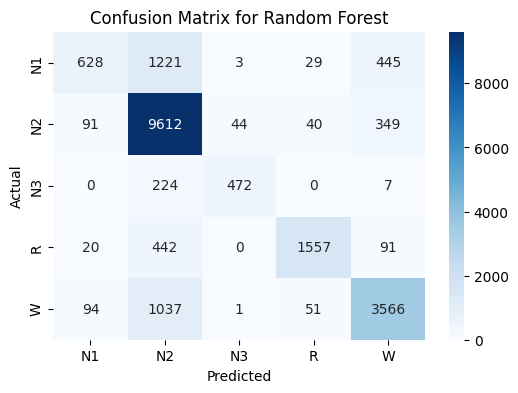


Classification Report for Random Forest:

Model Training Score: 0.95
Accuracy: 0.79
Balanced Accuracy: 0.68
Precision (weighted): 0.80
Recall (weighted): 0.79
F1 Score (weighted): 0.77
F2 Score (weighted): 0.78
              precision    recall  f1-score   support

          N1       0.75      0.27      0.40      2326
          N2       0.77      0.95      0.85     10136
          N3       0.91      0.67      0.77       703
           R       0.93      0.74      0.82      2110
           W       0.80      0.75      0.77      4749

    accuracy                           0.79     20024
   macro avg       0.83      0.68      0.72     20024
weighted avg       0.80      0.79      0.77     20024

--------------------------------------------------


In [ ]:
# Random Forest Model
rf_model_tuned = RandomForestClassifier(n_estimators=200, random_state=42,
                                        class_weight='balanced',criterion = 'entropy',
                                        min_samples_split= 5, min_samples_leaf= 2, max_depth = 15,)
rf_model_tuned.fit(x_train, y_train)
y_pred_rft = rf_model_tuned.predict(x_test)

evaluate_model("Random Forest", rf_model_tuned, y_pred_rf, x_train, y_train, y_test,le)

In [ ]:
test_data_dir = "/content/test_segment"
submission_file = "submission1.csv"

In [ ]:
import os

print(f"Contents of {test_data_dir}:")
print(os.listdir(test_data_dir))


Contents of /content/test_segment:
['test_segment']


ลองเอา file process ทีละ file แล้ว add เข้า df พร้อม segment_id

In [ ]:
from tqdm import tqdm

# Define a function to process segments
def process_segments2(df, window_size):
    num_segments = len(df) // window_size  # Number of 30-second windows processed_data
    test_processed_data = []
    for i in tqdm(range(num_segments), desc="Processing Segments", unit="window"):
        start_idx = i * window_size
        end_idx = (i + 1) * window_size
        segment = df.iloc[start_idx:end_idx]  # Extract 30-second segment
        feature_dict = {}

        feature_dict['segment_id'] = segment.iloc[0]['segment_id']

        for col in df.columns[:-1]:  # Exclude the last column (assumed to be Sleep Stage)
            data = segment[col].values
            # Time-domain features
            feature_dict[f'{col}_mean'] = np.mean(data)
            feature_dict[f'{col}_std'] = np.std(data)
            feature_dict[f'{col}_mad'] = np.median(np.abs(data - np.median(data)))
            feature_dict[f'{col}_max'] = np.max(data)
            feature_dict[f'{col}_min'] = np.min(data)
            feature_dict[f'{col}_sma'] = np.sum(np.abs(data))  # Signal Magnitude Area
            feature_dict[f'{col}_energy'] = np.sum(np.square(data))
            feature_dict[f'{col}_iqr'] = iqr(data)
            feature_dict[f'{col}_skewness'] = skew(data)
            feature_dict[f'{col}_kurtosis'] = kurtosis(data)

        # Assign the sleep stage (take the first row's label)
        # feature_dict['Sleep_Stage'] = segment.iloc[0, -1]
        test_processed_data.append(feature_dict)  # Store in list
    return test_processed_data

# Define paths


In [ ]:
test_csv_files = []
test_df_list = []  # List to hold dataframes for concatenation

for root, dirs, files in os.walk(test_data_dir):
    for f in files:
        if f.endswith(".csv"):
            test_csv_files.append(os.path.join(root, f))

# Check if any CSV files were found
if not test_csv_files:
    print("No CSV files found!")
else:
    # Read CSV files and add segment IDs
    for file in test_csv_files:
        # Extract segment ID from filename (e.g., test001_00691 from test001_00691.csv)
        segment_id = os.path.basename(file).replace(".csv", "")

        # Read CSV and add segment ID column
        df = pd.read_csv(file)
        df["segment_id"] = segment_id  # Tag each row with its segment

        test_df_list.append(df)

    # Concatenate all test data into a single DataFrame
    test_df = pd.concat(test_df_list, ignore_index=True)
    print("Concatenated DataFrame shape:", test_df.shape)

# Step 2: Process segments
test_processed_data = process_segments2(test_df, window_size)
test_df_processed = pd.DataFrame(test_processed_data)

# Display processed data
print("Processed DataFrame shape:", test_df_processed.shape)
print(test_df_processed.head())

Concatenated DataFrame shape: (3759360, 9)


Processing Segments:   0%|          | 0/7832 [00:00<?, ?window/s]<ipython-input-32-627a2b305a66>:26: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  feature_dict[f'{col}_skewness'] = skew(data)
<ipython-input-32-627a2b305a66>:27: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  feature_dict[f'{col}_kurtosis'] = kurtosis(data)
Processing Segments: 100%|██████████| 7832/7832 [01:45<00:00, 74.02window/s]


Processed DataFrame shape: (7832, 81)
      segment_id  BVP_mean    BVP_std    BVP_mad     BVP_max     BVP_min  \
0  test010_00187  0.076677  75.241066  62.524697  137.460593 -177.322571   
1  test010_00503 -0.355170  51.635950  33.169766  270.837160 -292.510051   
2  test010_00292 -0.337334  92.941424  80.985395  157.381960 -168.615858   
3  test010_00667 -0.313208  39.435082  32.739268   73.200221  -82.511489   
4  test010_00288 -0.602699  91.848067  78.965567  155.921235 -163.156130   

        BVP_sma    BVP_energy     BVP_iqr  BVP_skewness  ...  IBI_mean  \
0  31129.793938  2.717387e+06  123.528032     -0.181690  ...  0.638888   
1  18538.481273  1.279871e+06   67.582178      0.028430  ...  0.906760   
2  38533.598504  4.146347e+06  157.299147     -0.034842  ...  0.693190   
3  16441.389035  7.465074e+05   67.567390     -0.167311  ...  0.768826   
4  38059.653120  4.049487e+06  158.008933     -0.044876  ...  0.696494   

    IBI_std   IBI_mad   IBI_max   IBI_min     IBI_sma  IBI_e

In [ ]:
test_df_processed

,segment_id,BVP_mean,BVP_std,BVP_mad,BVP_max,BVP_min,BVP_sma,BVP_energy,BVP_iqr,BVP_skewness,...,IBI_mean,IBI_std,IBI_mad,IBI_max,IBI_min,IBI_sma,IBI_energy,IBI_iqr,IBI_skewness,IBI_kurtosis
0,test010_00187,0.076677,75.241066,62.524697,137.460593,-177.322571,31129.793938,2.717387e+06,123.528032,-0.181690,...,0.638888,0.017098,0.014848,0.681369,0.600754,306.666034,196.065442,0.016030,0.600253,0.187461
1,test010_00503,-0.355170,51.635950,33.169766,270.837160,-292.510051,18538.481273,1.279871e+06,67.582178,0.028430,...,0.906760,0.103989,0.061172,1.188370,0.708968,435.244873,399.853296,0.110255,0.370657,0.388774
2,test010_00292,-0.337334,92.941424,80.985395,157.381960,-168.615858,38533.598504,4.146347e+06,157.299147,-0.034842,...,0.693190,0.022564,0.015601,0.742808,0.645156,332.731430,230.890654,0.031229,-0.124279,-0.651596
3,test010_00667,-0.313208,39.435082,32.739268,73.200221,-82.511489,16441.389035,7.465074e+05,67.567390,-0.167311,...,0.768826,0.032326,0.030171,0.852315,0.708689,369.036260,284.226103,0.046448,0.302849,-0.498455
4,test010_00288,-0.602699,91.848067,78.965567,155.921235,-163.156130,38059.653120,4.049487e+06,158.008933,-0.044876,...,0.696494,0.019117,0.015369,0.729423,0.645279,334.317127,233.025292,0.030837,-0.290985,-0.592784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7827,test004_00591,0.640407,49.528852,32.699430,86.323418,-107.049971,20545.094499,1.177688e+06,81.646638,-0.540761,...,1.184811,0.140827,0.106789,1.465433,0.978310,568.709394,683.332778,0.259651,-0.101275,-0.951364
7828,test004_00457,-0.081519,40.070899,24.649119,66.990013,-80.395657,16592.314924,7.707281e+05,63.706982,-0.498104,...,1.222410,0.059392,0.040064,1.366467,1.106848,586.757005,718.951062,0.072025,0.414629,-0.173251
7829,test004_00154,-0.004739,76.865944,57.183506,140.745906,-132.815193,31872.914777,2.836019e+06,120.235503,-0.088538,...,1.236178,0.060212,0.031890,1.455029,1.133263,593.365607,735.245966,0.069890,1.251756,2.677409
7830,test004_00649,0.439326,29.397430,19.674671,57.621419,-59.198355,12068.247887,4.149129e+05,47.591951,-0.358385,...,1.199582,0.116100,0.080945,1.460787,0.983459,575.799535,697.189015,0.139445,0.225179,-0.234918


In [ ]:
f468 = pd.read_csv(r"/content/test_segment/test_segment/test008/test008_00468.csv")
f468

,BVP,ACC_X,ACC_Y,ACC_Z,TEMP,EDA,HR,IBI
0,13.708784,40.530677,-44.655880,9.861970,35.657120,1.574149,48.606866,1.158908
1,-0.805962,40.530677,-44.223475,9.919013,35.657094,1.574412,48.582804,1.157552
2,-15.402377,40.530677,-44.106151,9.845801,35.657150,1.574291,48.589064,1.159328
3,-30.578319,40.530676,-44.590451,9.924443,35.657039,1.573960,48.586743,1.157377
4,-51.277533,40.530678,-44.422646,9.864359,35.657200,1.578790,48.586957,1.158895
...,...,...,...,...,...,...,...,...
475,0.703777,40.530673,-44.488365,9.885556,35.657440,1.499422,48.509255,1.096386
476,-12.299370,40.530677,-44.479589,9.885503,35.656733,1.501123,48.506983,1.096573
477,-24.055670,40.530679,-44.491118,9.885554,35.657182,1.502457,48.509007,1.097005
478,-39.156624,40.530673,-44.477662,9.885517,35.657319,1.501935,48.508265,1.095669


In [ ]:
print(test_df_processed.shape)
# (66473, 81)

(7832, 81)


In [ ]:
tst_df_processed = test_df_processed.drop(columns=['segment_id'])
id = test_df_processed['segment_id']
predictions = rf_model_tuned.predict(tst_df_processed)
decoded_predictions = decoded_y_pred = le.inverse_transform(predictions)

# Step 6: Map predictions back to segment IDs
processed_results = pd.DataFrame({
    "id": id,
    "labels": decoded_predictions
})

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
unique_labels, counts = np.unique(decoded_predictions, return_counts=True)
print(dict(zip(unique_labels, counts)))

{'N1': 321, 'N2': 5711, 'N3': 1, 'R': 178, 'W': 1621}


In [ ]:
processed_results['labels'].value_counts()

,count
labels,
N,5966
W,898
R,146


In [ ]:
processed_results

,id,labels
0,test008_00468,N
1,test008_00034,N
2,test008_00207,N
3,test008_00337,N
4,test008_00471,N
...,...,...
7005,test009_00164,N
7006,test009_00323,N
7007,test009_00243,N
7008,test009_00468,N


ใช้อันนี้

In [ ]:
sample_submission = pd.read_csv('/content/sample_submission.csv')

# Ensure the sequence is aligned
final_results = processed_results.set_index('id').reindex(sample_submission['id']).reset_index()

# Step 6: Save the final result (ensure 'id' and 'labels' are in the correct order)
final_results.to_csv('/content/final_submission.csv', index=False)

In [ ]:
final_results

,id,labels
0,test001_00000,N
1,test001_00001,W
2,test001_00002,W
3,test001_00003,W
4,test001_00004,N
...,...,...
7005,test010_00696,R
7006,test010_00697,N
7007,test010_00698,N
7008,test010_00699,W


In [ ]:
# Load the sample submission format
submission_df = pd.read_csv("/content/sample_submission.csv")

# Check the structure of the sample submission to ensure the id column exists
print(submission_df.head())

# Now, ensure that the order of rows in submission_df matches the order of test_df
# Map the predictions back to the 'id' column of the sample submission
submission_df["id"] = test_df_processed["segment_id"]  # Ensure correct segment IDs in submission
submission_df["labels"] = decoded_predictions  # Fill the predictions

# Check if everything looks correct
print(submission_df.head())

# Save the final submission file
# submission_df.to_csv("final_submission.csv", index=False)


              id labels
0  test001_00000      W
1  test001_00001      W
2  test001_00002      W
3  test001_00003    NaN
4  test001_00004    NaN
              id labels
0  test008_00468      N
1  test008_00034      N
2  test008_00207      N
3  test008_00337      N
4  test008_00471      N


In [ ]:
submission_df

,id,labels
0,test008_00468,N
1,test008_00034,N
2,test008_00207,N
3,test008_00337,N
4,test008_00471,N
...,...,...
7005,test009_00164,N
7006,test009_00323,N
7007,test009_00243,N
7008,test009_00468,N


In [ ]:
expected_features = rf_model.feature_names_in_  # This works for sklearn >= 1.0

# Step 3: Rename test features to match training features (Fixes space/underscore mismatch)
test_df_processed.columns = [
    col.replace("_", " ") if col.replace("_", " ") in expected_features else col
    for col in test_df_processed.columns
]

# Step 4: Align feature order & handle missing features
test_df_processed = test_df_processed.reindex(columns=expected_features, fill_value=0)

# Step 5: Predict labels
predictions = rf_model.predict(test_df_processed)
decoded_predictions = np.array(class_labels)[np.argmax(predictions, axis=1)]

# Step 6: Map predictions back to segment IDs
processed_results = pd.DataFrame({
    "id": segment_ids,
    "labels": decoded_predictions
})





AttributeError: 'RandomForestClassifier' object has no attribute 'feature_names_in_'

In [ ]:
print(type(processed_results.to_csv))  # Should output <class 'method'>


<class 'method'>


In [ ]:
# processed_results.to_csv(r"submission9-rand.csv", index=False)

In [ ]:
train_class_indices = sorted(df_processed["Sleep_Stage"].unique())  # Replace with actual label column name
print("Class indices in training data:", train_class_indices)


Class indices in training data: ['N', 'R', 'W']


In [ ]:
predicted_indices = np.argmax(predictions, axis=1)  # If model output is probability
print("Predicted class indices:", np.unique(predicted_indices))

Predicted class indices: [0]
